# E43 · Transforming posteriors with coords: derived quantities, ranks, binning and re-indexing

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | NOAA GHCN-Daily: every daily maximum temperature at **Seattle-Tacoma** and **Portland** airports, 1948-2025 (57,000 station-days) |
| **You will learn** | Long table -> labelled `Dataset` (`to_xarray`, `to_dataset(dim=)`, `xr.concat` over a new named dim) · `xr.align` joins and what they silently do · non-dimension coords and `set_index`/`unstack` into year x day-of-year · one harmonic **basis as a DataArray** shared by the model and the posterior · derived quantities by broadcasting: climatology curves, warming per season, **a posterior over a date** with `idxmax` and `.interp` · exceedance probabilities and return periods on draws · **ranks** inside each draw (`apply_ufunc` + `rankdata`) · `groupby` arithmetic anomalies, `resample`, `BinGrouper`, multi-key `groupby`, `quantile` dims · `xr.apply_ufunc(vectorize=True)` to lift a SciPy root-finder over draws · warming stripes that show uncertainty, a climate spiral, ridgelines |

E01-E06 treat the posterior as something you summarise. Here it is something you
**compute with**. Almost every question a reader asks about a climate model - *when is the
hottest day of the year? has it moved? which year was the warmest? how often will it top
32 °C now?* - is a function of the parameters, and the honest answer is that function
evaluated **on every draw**, then summarised. The draws already carry names (`chain`,
`draw`, `station`, `k`, `part`, `year`); the whole trick of this notebook is to give every
other axis you invent along the way (day of year, decade, threshold, return period, rank)
a name too, and then let xarray line everything up. No `axis=2`, no `reshape`, no loops.

The model is deliberately modest - a seasonal cycle, a trend, a random effect per year and a
skewed daily scatter, fitted in about 20 seconds. Most of the notebook is what you do with it.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import PowerNorm, TwoSlopeNorm
from scipy import optimize, special, stats
from scipy.stats import gaussian_kde
from xarray.groupers import BinGrouper, UniqueGrouper

from pymc_challenges import data

RANDOM_SEED = 43
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
# xarray's FacetGrid calls tight_layout on the style's constrained-layout figures (harmless);
# SkewNormal prior draws run through scipy in numba object mode (harmless, but noisy).
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
warnings.filterwarnings("ignore", message="Numba will use object mode")

STATIONS = ["Sea-Tac", "Portland"]
COLOR = {"Sea-Tac": "#2a78d6", "Portland": "#d9822b"}
HOT = 32.0  # a "hot day" in the Pacific Northwest: about 90 °F


MONTHS = pd.date_range("2001-01-01", periods=12, freq="MS")[::2]  # tick every other month


def month_ticks(ax, axis="x"):
    getattr(ax, f"set_{axis}ticks")(MONTHS.dayofyear, MONTHS.strftime("%b"))


def doy_label(doy):
    """Day of year -> '05 Aug' (on a non-leap calendar)."""
    days = pd.to_timedelta(np.asarray(doy, dtype=float) - 1, unit="D")
    return (pd.Timestamp("2001-01-01") + days).strftime("%d %b")


print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, xarray {xr.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, xarray 2026.7.0


## 1 · From a long table to a labelled Dataset

GHCN-Daily ships one file per station, one row per (date, element) - `TMAX`, `TMIN`, `PRCP`,
snow, wind... - with values in tenths of a unit and a quality flag (blank = passed NOAA's
checks). The shortest route to a labelled array is: index the table by the two things that
will become dimensions, `to_xarray()`, and turn the `element` dimension into separate
variables with `to_dataset(dim="element")`.

In [2]:
data.describe("ghcnd_seatac")
data.describe("ghcnd_portland")


def station_dataset(name):
    """GHCN-Daily long table -> Dataset(TMAX, TMIN, PRCP) on a daily `time` axis."""
    raw = data.load(name)
    raw = raw[raw.element.isin(["TMAX", "TMIN", "PRCP"])]
    raw = raw.assign(time=pd.to_datetime(raw.date, format="%Y%m%d"),
                     value=raw.value.where(raw.qflag.isna()) / 10)  # failed QC -> NaN
    return raw.set_index(["time", "element"])["value"].to_xarray().to_dataset(dim="element")


sea = station_dataset("ghcnd_seatac")
pdx = station_dataset("ghcnd_portland")
sea

ghcnd_seatac: Every daily observation at Sea-Tac since 1948 in long format, no header: station id, date (YYYYMMDD), element (TMAX/TMIN in tenths of a degree C, PRCP, SNOW, ...), value, measurement / quality / source flags and observation time. A blank quality flag means the value passed NOAA's checks. The file is updated daily, so the latest year is partial.
  source: Menne et al. (2012), Global Historical Climatology Network - Daily (GHCN-Daily), NOAA National Centers for Environmental Information; station USW00024233 Seattle-Tacoma International Airport.
  url:    https://www.ncei.noaa.gov/pub/data/ghcn/daily/by_station/USW00024233.csv.gz
ghcnd_portland: Every daily observation at Portland airport since April 1938, same long format as ghcnd_seatac (TMAX in tenths of a degree C).
  source: Menne et al. (2012), Global Historical Climatology Network - Daily (GHCN-Daily), NOAA National Centers for Environmental Information; station USW00024229 Portland International Airport, Oregon.
  ur

<xarray.Dataset> Size: 920kB
Dimensions:  (time: 28754)
Coordinates:
  * time     (time) datetime64[us] 230kB 1948-01-01 1948-01-02 ... 2026-09-21
Data variables:
    PRCP     (time) float64 230kB 11.9 15.0 10.7 7.9 4.3 ... 0.0 0.0 0.0 0.0 0.0
    TMAX     (time) float64 230kB 10.6 7.2 7.2 7.2 7.2 ... 20.6 17.2 21.1 19.4
    TMIN     (time) float64 230kB 5.6 2.2 1.7 1.1 0.0 ... 12.8 11.1 10.0 11.1

**Alignment is where labelled data bites.** Sea-Tac starts in January 1948, Portland in
April 1938, and both files run into the current, unfinished year. Every binary operation
between them *aligns first*, and the default for arithmetic is an **inner** join: the
decade of Portland data before 1948 disappears without a word. `xr.align` lets you choose,
and `join="exact"` is the defensive setting when you believe the axes already match.

In [3]:
for join in ["inner", "outer", "left"]:
    a, b = xr.align(sea, pdx, join=join)
    print(f"join={join:5s}: {a.sizes['time']:6d} days, "
          f"Sea-Tac NaN-filled days: {int(a.TMAX.isnull().sum()):5d}")
print("sea.TMAX - pdx.TMAX keeps", (sea.TMAX - pdx.TMAX).sizes["time"], "days (inner join)")
try:
    xr.align(sea, pdx, join="exact")
except ValueError as err:  # xarray raises AlignmentError, a ValueError subclass
    print("join=exact:", type(err).__name__)

join=inner:  28754 days, Sea-Tac NaN-filled days:     1
join=outer:  32316 days, Sea-Tac NaN-filled days:  3563
join=left :  28754 days, Sea-Tac NaN-filled days:     1
sea.TMAX - pdx.TMAX keeps 28754 days (inner join)
join=exact: AlignmentError


To analyse the stations together we stack them along a **new named dimension**. Passing a
`pd.Index` with a name to `xr.concat` creates the `station` dimension and its labels in one
go; `join="outer"` keeps every day of both and NaN-fills the gaps, which we then cut to the
common complete years. (`dtype=object` matters under pandas 3: a list of strings becomes a
pandas `StringDtype` index, which xarray keeps, and a later `concat` with ordinary NumPy
string labels then fails with "Cannot interpret StringDtype as a data type".) Derived
calendar quantities go on as **non-dimension coordinates** along `time`: they travel with
every selection, and `groupby` can use them.

In [4]:
ds = xr.concat([sea, pdx], dim=pd.Index(STATIONS, name="station", dtype=object), join="outer")
ds = ds.sel(time=slice("1948", "2025"))
ds = ds.assign_coords(year=ds.time.dt.year, doy=ds.time.dt.dayofyear,
                      season=ds.time.dt.season)
print("missing TMAX days per station:", ds.TMAX.isnull().sum("time").to_series().to_dict())
ds

missing TMAX days per station: {'Sea-Tac': 1, 'Portland': 0}


<xarray.Dataset> Size: 2MB
Dimensions:  (station: 2, time: 28490)
Coordinates:
  * station  (station) object 16B 'Sea-Tac' 'Portland'
  * time     (time) datetime64[us] 228kB 1948-01-01 1948-01-02 ... 2025-12-31
    year     (time) int64 228kB 1948 1948 1948 1948 1948 ... 2025 2025 2025 2025
    doy      (time) int64 228kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
    season   (time) <U3 342kB 'DJF' 'DJF' 'DJF' 'DJF' ... 'DJF' 'DJF' 'DJF'
Data variables:
    PRCP     (station, time) float64 456kB 11.9 15.0 10.7 7.9 ... 0.0 0.0 0.0
    TMAX     (station, time) float64 456kB 10.6 7.2 7.2 7.2 ... 7.2 7.8 9.4 8.9
    TMIN     (station, time) float64 456kB 5.6 2.2 1.7 1.1 ... 0.6 0.0 -1.7 -0.6

A daily series 28,490 steps long hides its structure. Re-indexing `time` by the pair
(`year`, `doy`) and unstacking turns it into a year x day-of-year grid - the same numbers,
now arranged so that the seasonal cycle runs across and the decades run up. Everything
in this pipeline is by name: a 7-day centred rolling mean, the re-index, the facet by
station.

{'station': 2, 'year': 78, 'doy': 366}


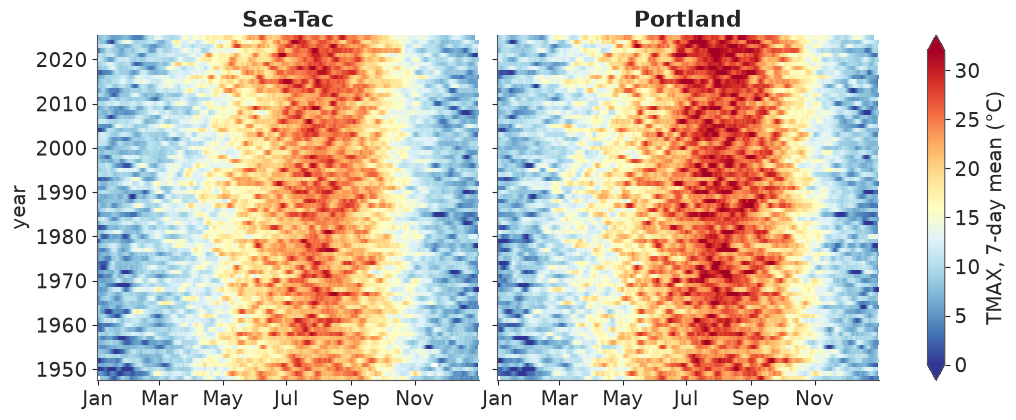

In [5]:
grid = (ds.TMAX.rolling(time=7, center=True).mean()
        .set_index(time=["year", "doy"]).unstack("time"))
print(dict(grid.sizes))
fg = grid.plot(col="station", x="doy", y="year", cmap="RdYlBu_r", vmin=0, vmax=32,
               figsize=(11, 4.6), cbar_kwargs={"label": "TMAX, 7-day mean (°C)"})
for ax, st in zip(fg.axs.flat, STATIONS):
    month_ticks(ax)
    ax.set(xlabel="", title=st);

Portland (right) is hotter in summer and its summer is longer than Sea-Tac's (left) - the
width of the red band. Individual hot spells show up as short dark-red streaks, and the
band is visibly wider and darker in the last decade or two at both stations. The grid is
not quite a calendar: in leap years every day after 28 February moves one column right, and
only leap years fill column 366. At a 7-day smoothing that shift is invisible, but it is the
reason we model on `doy` with a 365.25-day period rather than on columns of this grid.

**How independent are consecutive days?** Anomalies from the day-of-year average are the
classic xarray idiom: `groupby("time.dayofyear")` and subtract the grouped mean - xarray
broadcasts each group's value back onto its days. `xr.corr` with `shift` then gives the
autocorrelation at any lag, for both stations at once.

In [6]:
emp_clim = ds.TMAX.groupby("time.dayofyear").mean()
emp_anom = ds.TMAX.groupby("time.dayofyear") - emp_clim
lags = [1, 2, 3, 7, 14]
acf = xr.concat([xr.corr(emp_anom, emp_anom.shift(time=lag), dim="time") for lag in lags],
                dim=pd.Index(lags, name="lag"))
acf.round(2).to_pandas()

station,Sea-Tac,Portland
lag,,
1,0.67,0.67
2,0.41,0.41
3,0.28,0.27
7,0.13,0.11
14,0.08,0.07


Tomorrow is correlated 0.67 with today, but a week apart the correlation is down to about
0.12. A model that treats days as independent would count one heat wave as seven pieces of
evidence and report intervals far too narrow. The simplest honest fix for a notebook whose
subject is not autocorrelation: **fit on every 7th day** (4,070 days per station) and keep
the other six days of every week as held-out data for checking the model.

## 2 · A modest model, written on the same labels

For station $s$, year $y$ and day of year $d$ with $\omega = 2\pi d/365.25$ and time
$t$ in decades from 1987:

$$
\begin{aligned}
\text{TMAX} &\sim \text{SkewNormal}(\text{mean}=m,\ \text{sd}=\sigma,\ \text{skew}=\alpha)\\
m &= a_s + b_s t + u_{s,y} + \sum_{k=1}^{3}\big(c_{s,k}^{\cos}\cos k\omega
     + c_{s,k}^{\sin}\sin k\omega\big)
     + t\,\big(d_s^{\cos}\cos\omega + d_s^{\sin}\sin\omega\big)\\
\log\sigma &= l_s + g_s^{\cos}\cos\omega + g_s^{\sin}\sin\omega, \qquad
\alpha = e_s + h_s^{\cos}\cos\omega + h_s^{\sin}\sin\omega, \qquad u_{s,y}\sim N(0,\tau_s)
\end{aligned}
$$

Three harmonics give the seasonal cycle, $b$ is the warming per decade, $d$ lets the
*seasonal* cycle change over time (summers may warm faster than winters), $u$ is a warm or
cool year, and the daily scatter is skewed with a skewness that changes through the year:
winter highs have a long cold tail (arctic outbreaks), spring and summer highs a long hot
tail (heat waves).

**The basis is a DataArray.** The harmonics are written once, as a function of a labelled
`doy`, with named `k` and `part` dimensions matching the model's coords. The model uses its
values on the observed rows; later, the *same function* evaluated on any grid of days
broadcasts against the posterior draws by name.

In [7]:
K = 3
T_MID = 1987.0


def harmonics(doy):
    """cos/sin(2 pi k doy / 365.25) with dims (*doy.dims, k, part)."""
    k = xr.DataArray(np.arange(1, K + 1), dims="k", coords={"k": np.arange(1, K + 1)})
    w = 2 * np.pi * doy / 365.25
    part = pd.Index(["cos", "sin"], name="part", dtype=object)
    return xr.concat([np.cos(k * w), np.sin(k * w)], dim=part)


def decades(year, doy):
    """Time in decades since T_MID (mid-day of year `year`, day `doy`)."""
    return (year + (doy - 0.5) / 365.25 - T_MID) / 10


# every 7th day, then one row per (station, day) with a value
rows = ds.TMAX.isel(time=slice(None, None, 7)).stack(obs=("station", "time")).dropna("obs")
H_obs = harmonics(rows.doy).transpose("obs", "k", "part").values
t_obs = decades(rows.year, rows.doy).values
s_idx = pd.Index(STATIONS).get_indexer(rows.station.values)
YEARS = np.arange(1948, 2026)
y_idx = rows.year.values - YEARS[0]
print(f"{rows.sizes['obs']} rows; per station:",
      rows.groupby("station").count().to_series().to_dict())

8140 rows; per station: {'Portland': 4070, 'Sea-Tac': 4070}


One modelling detail matters for sampling. PyMC's `SkewNormal(mu, sigma, alpha)` uses the
*direct* parametrisation, where `mu` is a location that moves whenever the skewness moves.
Written that way, this model sampled into different modes per chain (r_hat 2.4 on the
intercept and the skewness harmonics). Parametrising by the **mean and sd** - converting to
the direct parameters inside the model - removes the trade-off, and the mean is also the
quantity we want to talk about. The same function builds a plain Normal version, which we
will need in section 5.

In [8]:
def sn_direct(mean, sd, alpha):
    """Skew-normal mean / sd / alpha -> direct (xi, omega). Works on tensors and arrays."""
    delta = alpha / np.sqrt(1 + alpha**2)
    omega = sd / np.sqrt(1 - 2 * delta**2 / np.pi)
    return mean - omega * delta * np.sqrt(2 / np.pi), omega


coords = {"station": STATIONS, "year": YEARS, "k": np.arange(1, K + 1), "part": ["cos", "sin"],
          "obs": np.arange(rows.sizes["obs"])}


def build_model(skewed=True):
    with pm.Model(coords=coords) as model:
        a = pm.Normal("a", 15, 5, dims="station")
        b = pm.Normal("b", 0, 0.5, dims="station")            # deg C per decade
        c = pm.Normal("c", 0, 5, dims=("station", "k", "part"))
        d = pm.Normal("d", 0, 0.5, dims=("station", "part"))  # change of the cycle per decade
        tau = pm.HalfNormal("tau", 1, dims="station")
        z = pm.Normal("z", 0, 1, dims=("station", "year"))
        u = pm.Deterministic("u", z * tau[:, None], dims=("station", "year"))
        ls = pm.Normal("ls", np.log(3.5), 0.5, dims="station")
        g = pm.Normal("g", 0, 0.5, dims=("station", "part"))

        H1 = H_obs[:, 0, :]  # first harmonic, (obs, part)
        mean = (a[s_idx] + b[s_idx] * t_obs + u[s_idx, y_idx]
                + (c[s_idx] * H_obs).sum(axis=(1, 2)) + t_obs * (d[s_idx] * H1).sum(axis=1))
        sd = pm.math.exp(ls[s_idx] + (g[s_idx] * H1).sum(axis=1))
        if skewed:
            e = pm.Normal("e", 0, 2, dims="station")
            h = pm.Normal("h", 0, 2, dims=("station", "part"))
            alpha = e[s_idx] + (h[s_idx] * H1).sum(axis=1)
            xi, omega = sn_direct(mean, sd, alpha)
            pm.SkewNormal("tmax", mu=xi, sigma=omega, alpha=alpha, observed=rows.values,
                          dims="obs")
        else:
            pm.Normal("tmax", mu=mean, sigma=sd, observed=rows.values, dims="obs")
    return model


skew_model = build_model(skewed=True)
prior = pm.sample_prior_predictive(draws=200, model=skew_model, random_seed=RANDOM_SEED)
qs = [0.01, 0.5, 0.99]
print("prior predictive TMAX quantiles:",
      prior.prior_predictive["tmax"].quantile(qs).round(1).values,
      "| observed:", rows.quantile(qs).round(1).values)

Sampling: [a, b, c, d, e, g, h, ls, tau, tmax, z]


prior predictive TMAX quantiles: [-13.   14.6  43. ] | observed: [ 1.1 15.6 33.9]


The priors allow daily maxima from well below freezing to the low 40s °C - wider than the
data, nowhere absurd. The prior on $b$ (sd 0.5 °C per decade) is generous: the observed
warming is a few tenths of a degree per decade.

In [9]:
idata = pm.sample(model=skew_model, random_seed=RANDOM_SEED, progressbar=False)
idata_normal = pm.sample(model=build_model(skewed=False), random_seed=RANDOM_SEED,
                         progressbar=False)

for name, fit in [("skew-normal", idata), ("normal", idata_normal)]:
    rhat = az.rhat(fit.posterior).to_dataset().to_dataarray().max()
    ess = az.ess(fit.posterior).to_dataset().to_dataarray().min()
    print(f"{name:12s} max r_hat {float(rhat):.3f}  min ESS {float(ess):.0f}  "
          f"divergences {int(fit.sample_stats['diverging'].sum())}  "
          f"({fit.posterior.attrs['sampling_time']:.0f} s, "
          f"{fit.posterior.attrs['tuning_steps']} tuning steps)")
az.summary(idata, var_names=["a", "b", "d", "tau", "e", "h"], round_to=3)

NUTS[nutpie]: [a, b, c, d, tau, z, ls, g, e, h]


NUTS[nutpie]: [a, b, c, d, tau, z, ls, g]


skew-normal  max r_hat 1.006  min ESS 1636  divergences 0  (22 s, 400 tuning steps)


normal       max r_hat 1.006  min ESS 1493  divergences 0  (5 s, 400 tuning steps)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[Sea-Tac],15.423,0.089,15.280,15.566,2802.507,2811.474,1.001,0.002,0.001
a[Portland],17.119,0.085,16.984,17.255,3916.283,2818.584,1.002,0.001,0.001
b[Sea-Tac],0.234,0.039,0.172,0.294,3018.431,2843.031,1.002,0.001,0.001
b[Portland],0.226,0.035,0.171,0.279,3957.140,3026.098,1.001,0.001,0.001
"d[Sea-Tac, cos]",-0.063,0.034,-0.119,-0.010,6855.961,2847.887,1.000,0.000,0.001
"d[Sea-Tac, sin]",-0.005,0.034,-0.059,0.050,6205.382,2616.235,1.004,0.000,0.001
"d[Portland, cos]",-0.048,0.037,-0.107,0.009,5575.982,2707.885,1.001,0.000,0.001
"d[Portland, sin]",-0.025,0.038,-0.086,0.036,6345.054,2626.140,1.002,0.000,0.001
tau[Sea-Tac],0.609,0.079,0.489,0.741,1635.728,2302.899,1.002,0.002,0.001
tau[Portland],0.465,0.086,0.332,0.603,1963.469,2273.539,1.001,0.002,0.001


Both fits are clean under nutpie: r_hat at most 1.01, ESS at least about 1,500 for every
parameter, no divergences, and under half a minute each. `az.rhat` on a group returns a
`DataTree` node; the `.to_dataset().to_dataarray()` detour turns "every variable" into one
array whose `.max()` is the worst r_hat anywhere.

The headline parameter is already readable: both airports warmed by about **0.23 °C per
decade** ($b$), about 1.8 °C over the 78 years. The skewness $\alpha$ is positive on
average ($e \approx 1$) with a strong negative cosine term ($h^{\cos}$): negative skew in
winter, positive in summer - just what the data suggested.

## 3 · Names, not positions

The posterior of `c` has five dimensions. Here is the same number twice.

In [10]:
c = idata.posterior["c"]
print(c.dims)
positional = c.values[:, :, 0, 0, 0].mean()   # which station? which harmonic? cos or sin?
named = c.sel(station="Sea-Tac", k=1, part="cos").mean().item()
print(f"positional {positional:.3f}   named {named:.3f}")
# reorder the dims (as a later concat, stack or apply_ufunc may) and repeat
c_moved = c.transpose("part", "k", "station", ...)
print(f"positional after transpose {c_moved.values[:, :, 0, 0, 0].mean():.3f}   "
      f"named {c_moved.sel(station='Sea-Tac', k=1, part='cos').mean().item():.3f}")

('chain', 'draw', 'station', 'k', 'part')
positional -8.012   named -8.012
positional after transpose -1.548   named -8.012


`values[:, :, 0, 0, 0]` silently means something else as soon as any step reorders the
dimensions - and it would not even raise. From here on everything is selected, reduced and
broadcast by name. We pool chains and draws into one `sample` dimension with `az.extract`
(500 random draws are plenty for the summaries below and keep every array small).

Two label details. `az.extract` indexes `sample` by a (chain, draw) MultiIndex; two
random extracts - say from two different models - carry *different* labels, and combining
them later would outer-join 250 + 250 samples into 500 half-NaN ones (xarray currently
warns that this default will become `join="exact"`). Draws from different fits are not
paired anyway, so we replace the MultiIndex by a plain counter. And the station labels are
re-attached as `object` strings so they match `ds` exactly.

In [11]:
def draws(fit, n):
    """n random posterior draws with a plain integer `sample` index."""
    p = az.extract(fit, num_samples=n, random_seed=RANDOM_SEED)
    return (p.drop_vars(["sample", "chain", "draw"])
            .assign_coords(sample=np.arange(n), station=np.array(STATIONS, dtype=object)))


post = draws(idata, 500)
print(dict(post.sizes))

{'station': 2, 'sample': 500, 'k': 3, 'part': 2, 'year': 78}


## 4 · Derived quantities are functions of draws

A *derived quantity* is any function of the parameters. Write it once, as an ordinary
function of labelled arrays, and it works on one draw, on 500 draws, on any grid of days or
years you pass in - xarray broadcasts by dimension name. The model's expected TMAX (the
**climatology** - the average high for a given day in a given year's climate, before that
particular year's anomaly) and the daily spread:

In [12]:
def expected_tmax(p, year, doy):
    """Mean TMAX for the given year(s) and day(s) of year, excluding the year effect u."""
    t, H = decades(year, doy), harmonics(doy)
    return (p["a"] + p["b"] * t + xr.dot(p["c"], H, dim=["k", "part"])
            + t * xr.dot(p["d"], H.sel(k=1, drop=True), dim="part"))


def daily_spread(p, doy):
    """Daily sd and skewness on day(s) of year `doy`."""
    H1 = harmonics(doy).sel(k=1, drop=True)
    sd = np.exp(p["ls"] + xr.dot(p["g"], H1, dim="part"))
    return sd, p["e"] + xr.dot(p["h"], H1, dim="part")


doy = xr.DataArray(np.arange(1, 366), dims="doy", coords={"doy": np.arange(1, 366)})
decade = xr.DataArray(np.arange(1950, 2030, 10), dims="decade",
                      coords={"decade": np.arange(1950, 2030, 10)})
clim = expected_tmax(post, decade + 4.5, doy)   # the climate of each decade's mid-point
print(clim.dims, dict(clim.sizes))

('station', 'sample', 'decade', 'doy') {'station': 2, 'sample': 500, 'decade': 8, 'doy': 365}


Passing a `decade` array and a `doy` array produced a (station, sample, decade, doy) array:
2 x 500 x 8 x 365, no loop. The **warming per decade on each day of the year** is another
derived quantity - $b + d^{\cos}\cos\omega + d^{\sin}\sin\omega$ - and a `.quantile` over
`sample` gives a new `quantile` dimension to plot bands from.

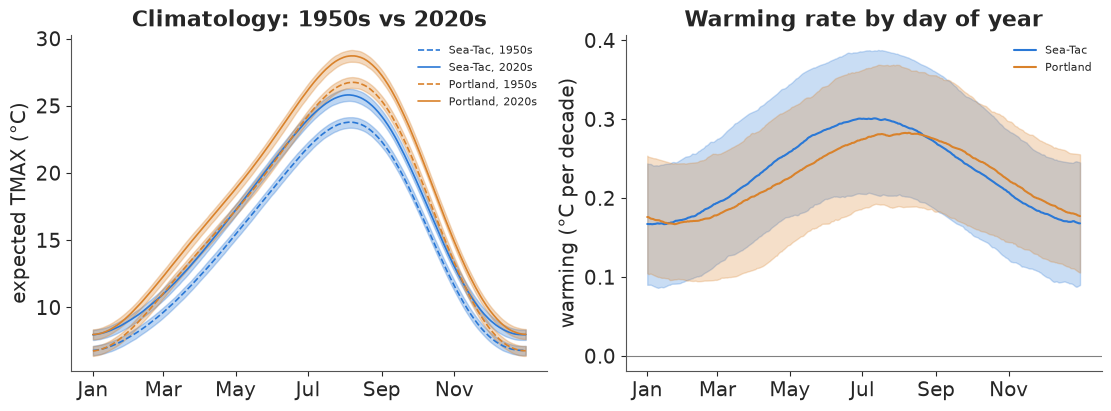

In [13]:
warming_rate = post["b"] + xr.dot(post["d"], harmonics(doy).sel(k=1, drop=True), dim="part")
band = [0.05, 0.5, 0.95]
clim_q = clim.sel(decade=[1950, 2020]).quantile(band, dim="sample")
rate_q = warming_rate.quantile(band, dim="sample")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for st in STATIONS:
    for dec, ls in [(1950, "--"), (2020, "-")]:
        q = clim_q.sel(station=st, decade=dec)
        axes[0].fill_between(doy, q.sel(quantile=0.05), q.sel(quantile=0.95), color=COLOR[st],
                             alpha=0.3)
        axes[0].plot(doy, q.sel(quantile=0.5), ls, color=COLOR[st], lw=1.2,
                     label=f"{st}, {dec}s")
    q = rate_q.sel(station=st)
    axes[1].fill_between(doy, q.sel(quantile=0.05), q.sel(quantile=0.95), color=COLOR[st],
                         alpha=0.25)
    axes[1].plot(doy, q.sel(quantile=0.5), color=COLOR[st], label=st)
axes[0].set(ylabel="expected TMAX (°C)", title="Climatology: 1950s vs 2020s")
axes[1].set(ylabel="warming (°C per decade)", title="Warming rate by day of year")
axes[1].axhline(0, color="0.5", lw=0.8)
for ax in axes:
    month_ticks(ax)
    ax.legend(fontsize=8)

On the scale of a 15 °C seasonal cycle, the 1.8 °C of warming is a modest but clearly
resolved gap between the dashed (1950s) and solid (2020s) curves: the 90% bands of the
*expected* high are only a few tenths of a degree wide. The right panel shows what the curves hide: warming is not uniform through the
year. At both stations the posterior median is highest in mid-summer (about 0.28-0.30 °C
per decade) and lowest in mid-winter (about 0.17).

The pointwise bands of the two seasons overlap, which tempts the conclusion "no evidence
of a difference". That reads the wrong quantity. The contrast *summer rate minus winter
rate* is itself a derived quantity - a difference of two `.sel`s, draw by draw - and its
posterior is what answers the question:

In [14]:
contrast = warming_rate.sel(doy=196) - warming_rate.sel(doy=15)      # 15 July minus 15 January
pd.DataFrame({"median (°C/decade)": contrast.median("sample").to_series(),
              "P(summer warmed faster)": (contrast > 0).mean("sample").to_series()}).round(3)

,median (°C/decade),P(summer warmed faster)
station,,
Sea-Tac,0.128,0.980
Portland,0.104,0.924


The summer-minus-winter difference in warming rate has a posterior median of about
0.13 °C per decade at Sea-Tac and 0.10 at Portland, and it is positive in 98% and 92% of
draws. Overlapping pointwise bands are not evidence of "no difference": the two rates share
$b$ within each draw, and the draw-by-draw difference cancels that shared uncertainty.

### A posterior over a date

`idxmax("doy")` returns the **label** of the maximum along a named dimension, so on the
climatology it gives the *date* of the hottest day of the average year - once per draw,
decade and station, i.e. a posterior distribution over a date. On a whole-day grid that
posterior is lumpy (it can only take integer values); `.interp` to a 0.1-day grid near the
peak (cubic, by name) smooths it. Because the climatology here is an explicit function we
could also evaluate it on the fine grid directly - and the answers agree to the grid step.

The same method answers a question with more movement: **when does summer arrive?** Take
"summer" as the part of the year when the average high is at least 21 °C (70 °F).
`(clim >= 21.1)` is a boolean array; `idxmax` on it returns the *first* day that is True
(the onset), and the length of summer is just `.sum("doy")`.

In [15]:
fine = np.arange(190, 245.01, 0.1)
peak = clim.sel(doy=slice(185, 250)).interp(doy=fine, method="cubic").idxmax("doy")
fine_doy = xr.DataArray(fine, dims="doy", coords={"doy": fine})
peak_direct = expected_tmax(post, decade + 4.5, fine_doy).idxmax("doy")
print("interp vs direct evaluation: max |difference|",
      f"{float(abs(peak - peak_direct).max()):.2f} days")

SUMMER = 21.1
fine_year = xr.DataArray(np.arange(100, 320.01, 0.25), dims="doy")
fine_year = fine_year.assign_coords(doy=fine_year)
is_summer = expected_tmax(post, decade + 4.5, fine_year) >= SUMMER
onset = is_summer.idxmax("doy")
end = is_summer.cumsum("doy").idxmax("doy")          # last day of the run
length = is_summer.sum("doy") * 0.25
date_post = xr.Dataset({"onset": onset, "peak": peak, "end": end, "length": length})
summary = date_post.mean("sample").sel(decade=[1950, 1980, 2020]).to_dataframe()
summary[["onset", "peak", "end"]] = summary[["onset", "peak", "end"]].map(doy_label)
summary.round(0)

interp vs direct evaluation: max |difference| 0.00 days


onset    peak     end  length
station  decade                                
Sea-Tac  1950    22 Jun  05 Aug  10 Sep    80.0
         1980    14 Jun  04 Aug  15 Sep    93.0
         2020    03 Jun  04 Aug  21 Sep   110.0
Portland 1950    04 Jun  07 Aug  26 Sep   114.0
         1980    29 May  07 Aug  30 Sep   124.0
         2020    21 May  07 Aug  04 Oct   137.0

The peak of the average year sits on about 4-5 August at Sea-Tac and 7 August at Portland,
and it has not moved (the decades differ by about a day, within a posterior sd of about
1.3 days). What has moved is everything around it: in the 1950s climate the average high
first reached 21 °C around 22 June at Sea-Tac, in the 2020s climate around 3 June; the
autumn end moved from about 10 to 21 September, and the summer grew from about 80 to
110 days. Portland's summer is longer at both ends and grew similarly.

A **ridgeline** makes the shift visible: one row per decade, the posterior density of the
onset, peak and end dates on a calendar axis. Every row is `date_post.sel(station=...,
decade=...)` - the draws of one cell of a labelled array.

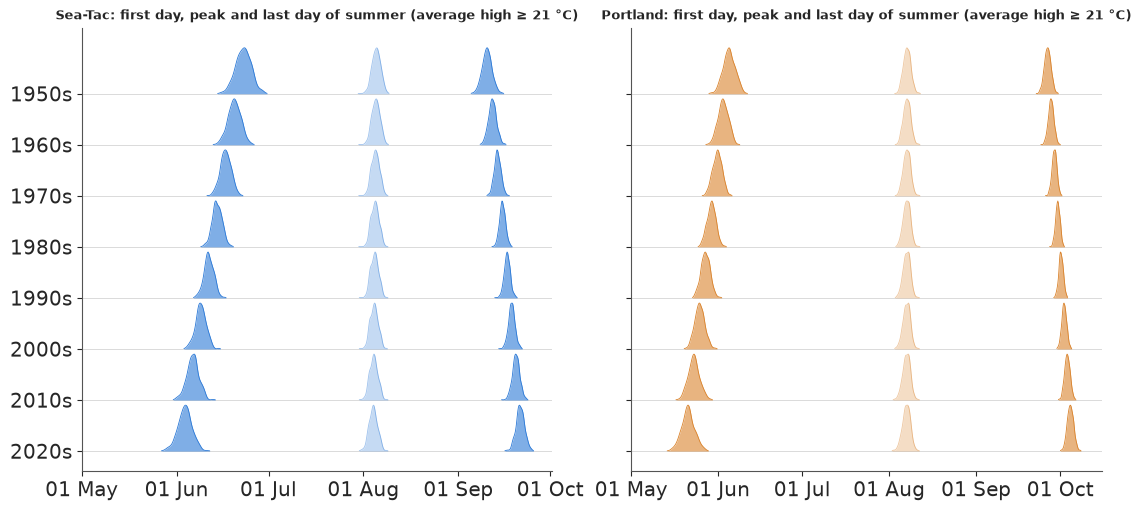

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
xs = np.linspace(125, 290, 900)
for ax, st in zip(axes, STATIONS):
    for i, dec in enumerate(decade.values):
        base = -i * 1.0
        for var, shade in [("onset", 1.0), ("peak", 0.45), ("end", 1.0)]:
            vals = date_post[var].sel(station=st, decade=dec).values
            dens = gaussian_kde(vals)(xs)
            dens = 0.9 * dens / dens.max()
            keep = dens > 0.005
            ax.fill_between(xs[keep], base, base + dens[keep], color=COLOR[st], alpha=shade * 0.6,
                            lw=0)
            ax.plot(xs[keep], base + dens[keep], color=COLOR[st], lw=0.6, alpha=shade)
        ax.axhline(base, color="0.8", lw=0.5, zorder=0)
    ax.set_yticks(-np.arange(len(decade)), [f"{d}s" for d in decade.values])
    first = pd.date_range("2001-05-01", periods=6, freq="MS")
    ax.set_xticks(first.dayofyear, first.strftime("%d %b"))
    ax.set_title(f"{st}: first day, peak and last day of summer (average high ≥ 21 °C)",
                 fontsize=9)

At both stations the onset ridges (left) walk steadily earlier decade by decade and the end
ridges (right) walk later, while the paler peak ridges in the middle stay on the same
August date. The ridges are narrow - a few days - because they are the posterior of
the *average* climate, not of any one year's weather. The onset moves further than the end
because the seasonal curve is flatter in June than in September, so the same warming shifts
the crossing of 21 °C by more days.

**The warming itself, two ways.** $b$ is the model's underlying trend. The latent annual
level $a + b\,t + u_y$ also includes each year's anomaly, and `.polyfit("year", 1)` - run on
a (station, sample, year) array - fits a line through every draw's 78 annual levels at once:
the *realised* 1948-2025 warming, with its own posterior. `.polyfit` on the raw annual means
is the no-model answer.

In [17]:
level = post["a"] + post["b"] * decades(post["year"], 183) + post["u"]
realised = level.polyfit("year", deg=1).polyfit_coefficients.sel(degree=1) * 10
annual_obs = ds.TMAX.groupby("year").mean()
raw_trend = annual_obs.polyfit("year", deg=1).polyfit_coefficients.sel(degree=1) * 10
diff = post["b"].sel(station="Portland") - post["b"].sel(station="Sea-Tac")
print(f"P(Portland warmed faster than Sea-Tac) = {float((diff > 0).mean()):.2f}")
pd.DataFrame({
    "trend b (°C/decade)": post["b"].mean("sample").to_series(),
    "b 90% interval": [f"{lo:.2f} to {hi:.2f}" for lo, hi in
                       post["b"].quantile([0.05, 0.95], "sample").T.values],
    "realised, polyfit on draws": realised.mean("sample").to_series(),
    "polyfit on raw annual means": raw_trend.to_series(),
}).round(3)

P(Portland warmed faster than Sea-Tac) = 0.46


,trend b (°C/decade),b 90% interval,"realised, polyfit on draws",polyfit on raw annual means
station,,,,
Sea-Tac,0.233,0.17 to 0.29,0.236,0.229
Portland,0.226,0.17 to 0.28,0.227,0.246


The three estimates agree to within 0.02 °C per decade: roughly 0.23 at both stations, with
90% intervals of about ±0.06. The two stations are indistinguishable (the posterior
probability that Portland warmed faster is near a coin flip) - the difference of two
labelled arrays selected by `station` is itself a posterior.

## 5 · Exceedance probabilities, return periods and a check on held-out days

How likely is a **hot day** (TMAX ≥ 32 °C) on a given date in a given year? For each draw
that is the upper tail of that day's skew-normal. Two xarray points here:

- `scipy.stats.skewnorm.sf` is not a NumPy ufunc, so calling it on DataArrays would return
  a bare NumPy array (labels gone). `xr.apply_ufunc` wraps it: inputs broadcast by name, the
  result keeps every dimension and coordinate.
- This time we *include* each year's anomaly $u$: `post["u"]` already has a `year`
  dimension, so adding it to a climatology evaluated on `post["year"]` lines up year by
  year - no index arithmetic.

We restrict to May-September and 250 draws to keep the array at 48 MB
(station x sample x doy x year = 2 x 250 x 153 x 78).

In [18]:
def tail_prob(threshold, mean, sd, alpha):
    """P(TMAX >= threshold) under the mean/sd/skew parametrisation, for labelled inputs."""
    xi, omega = sn_direct(mean, sd, alpha)
    return xr.apply_ufunc(stats.skewnorm.sf, threshold, alpha, xi, omega)


def p_hot(p, threshold=HOT):
    warm = doy.sel(doy=slice(121, 273))                         # 1 May - 30 Sep
    mean = expected_tmax(p, p["year"], warm) + p["u"]
    sd, alpha = daily_spread(p, warm)
    return tail_prob(threshold, mean, sd, alpha)


sub = post.isel(sample=slice(0, 250))
p_skew = p_hot(sub)
sub_n = draws(idata_normal, 250)
sub_n["e"], sub_n["h"] = xr.zeros_like(sub_n["b"]), xr.zeros_like(sub_n["d"])  # skew 0 = Normal
p_norm = p_hot(sub_n)
print(dict(p_skew.sizes), f"{p_skew.nbytes / 1e6:.0f} MB")

{'station': 2, 'sample': 250, 'doy': 153, 'year': 78} 48 MB


Setting the skewness to zero turns the same function into the Normal model's answer: we
just added two all-zero variables to the Normal posterior with `xr.zeros_like`, which copies
the right dims and coords.

The posterior mean of P(hot day) on every (day, year) is a picture of the changing climate.
Over it we put the **actual** hot days from the full daily record - most of which the model
never saw (six days out of seven were held out). `.where(..., drop=True)` pulls them out as a
short list.

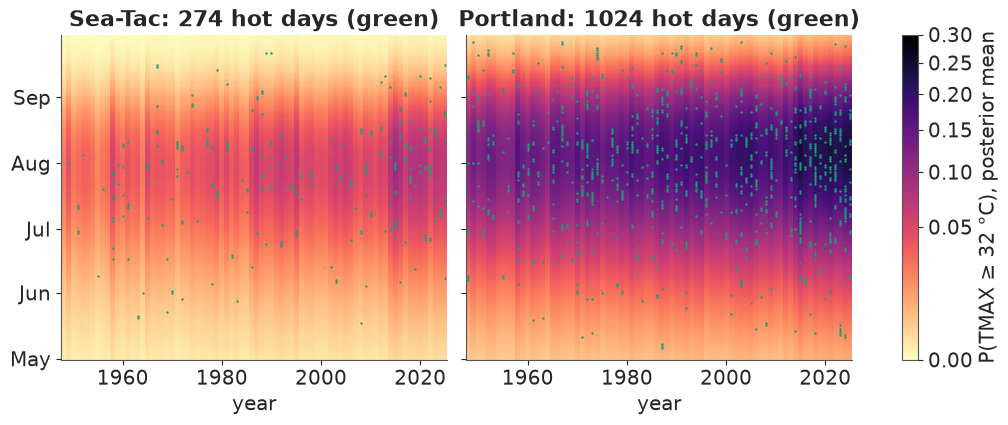

In [19]:
hot_obs = ds.TMAX.where(ds.TMAX >= HOT, drop=True)
fg = p_skew.mean("sample").plot(col="station", x="year", y="doy", cmap="magma_r",
                                norm=PowerNorm(0.5, vmin=0, vmax=0.3), figsize=(11, 4.4),
                                cbar_kwargs={"label": f"P(TMAX ≥ {HOT:.0f} °C), posterior mean"})
summer_months = pd.date_range("2001-05-01", periods=5, freq="MS")
for ax, st in zip(fg.axs.flat, STATIONS):
    days = hot_obs.sel(station=st).dropna("time")
    ax.scatter(days.year, days.doy, s=3, color="#1b9e77", lw=0)
    ax.set_title(f"{st}: {days.sizes['time']} hot days (green)")
    ax.set_yticks(summer_months.dayofyear, summer_months.strftime("%b"))
    ax.set_ylabel("");

(The colour scale is square-root so that Sea-Tac's small probabilities stay visible.) The
probability surface is a ridge centred on late July to early August that darkens toward
the present and flickers year to year with $u$ - hot years such as 1958 and 2015 are
darker columns. The observed hot days scatter over the dark part of each station's ridge.
Portland's ridge is much wider and darker: 32 °C is a common summer day there and a rare one
at Sea-Tac.

**A held-out check, by counting.** Summing over `doy` gives the expected number of hot
days per year; drawing one Bernoulli per day and summing gives the *predictive* count,
which is what an observed count should fall inside. We do this for both models and put
them side by side with `xr.concat` over a new `model` dimension, then compare with the
counts in the full daily record.

In [20]:
p_both = xr.concat([p_skew, p_norm],
                   dim=pd.Index(["skew-normal", "normal"], name="model", dtype=object))
hot_count = xr.apply_ufunc(rng.binomial, 1, p_both).sum("doy")      # predictive counts
observed_count = (ds.TMAX >= HOT).groupby("year").sum()
count_q = hot_count.quantile([0.05, 0.5, 0.95], dim="sample")
inside = ((observed_count >= count_q.sel(quantile=0.05))
          & (observed_count <= count_q.sel(quantile=0.95))).mean("year")
by_period = (xr.concat([hot_count.mean("sample"), observed_count.expand_dims(model=["observed"])],
                       dim="model")
             .groupby_bins("year", [1947, 1985, 2015, 2025],
                           labels=["1948-1985", "1986-2015", "2016-2025"]).mean())
print("share of years inside the 90% predictive interval:")
print(inside.round(2).to_pandas())
by_period.round(1).to_dataframe("hot days per year").unstack(["station", "model"])

share of years inside the 90% predictive interval:
model     skew-normal  normal
station                      
Sea-Tac          0.79    0.71
Portland         0.68    0.60


hot days per year                                               
station             Sea-Tac    Portland Sea-Tac Portland  Sea-Tac Portland
model           skew-normal skew-normal  normal   normal observed observed
year_bins                                                                 
1948-1985               2.3        10.2     1.2      8.1      2.6      9.9
1986-2015               3.6        13.3     2.2     12.0      3.5     14.2
2016-2025               4.7        16.6     3.2     15.9      7.2     22.1

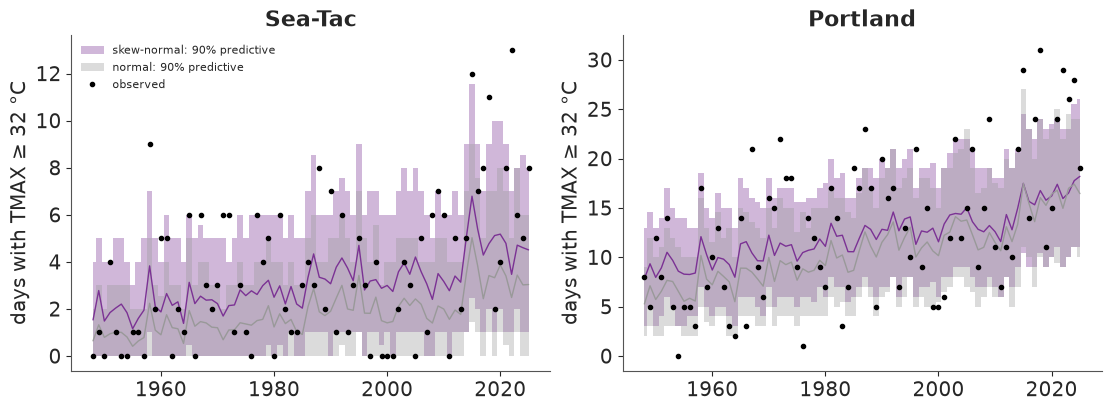

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
styles = {"skew-normal": ("#7b3294", 0.35), "normal": ("#999999", 0.35)}
for ax, st in zip(axes, STATIONS):
    for mdl, (col, al) in styles.items():
        q = count_q.sel(station=st, model=mdl)
        ax.fill_between(q.year, q.sel(quantile=0.05), q.sel(quantile=0.95), color=col, alpha=al,
                        step="mid", lw=0, label=f"{mdl}: 90% predictive")
        ax.plot(q.year, hot_count.sel(station=st, model=mdl).mean("sample"), color=col, lw=1)
    ax.plot(observed_count.year, observed_count.sel(station=st), "o", ms=3, color="k",
            label="observed")
    ax.set(title=st, ylabel=f"days with TMAX ≥ {HOT:.0f} °C")
axes[0].legend(fontsize=8);

This is the check that separates the two likelihoods. With a Normal daily scatter (grey)
the model **misses the hot tail**: at Sea-Tac it expects about half the hot days actually
seen (1.2 against 2.6 a year before 1986), and only 71% (Sea-Tac) and 60% (Portland) of
years fall inside its 90% interval. The skew-normal (purple) gets the long-run rate about
right up to 2015 at both stations (2.3 against 2.6 and 3.6 against 3.5 a year at Sea-Tac;
10.2 against 9.9 and 13.3 against 14.2 at Portland), but two failures remain that no
amount of skewness fixes:

- only 79% and 68% of years fall inside its 90% interval: the observed counts are **more
  variable** than predicted, with misses on both sides and more above. Real hot days come
  in heat waves; our daily draws are independent, so the predictive count is too
  well-behaved;
- since about 2015 both stations have had many more hot days than even the skew-normal
  expects (7.2 against 4.7 a year at Sea-Tac, 22.1 against 16.6 at Portland): recent summers
  have warmed faster than a straight-line trend.

That is useful to know before quoting any number below: the model's daily tail is
reasonable on average, its heat-wave clustering is absent, and extremes are the place it is
least trustworthy. (E37 models the hottest day of the year directly with extreme-value
theory, which is the right tool for record-breaking events.)

**Return periods of a 35 °C day.** Assuming independent days, the probability that a year
has at least one day at or above 35 °C is $1-\prod_d (1-p_d)$ - a product over the `doy`
dimension, computed in log space - and its reciprocal is the return period in years. We
evaluate it at the mid-points of the two halves of the record (1967 and 2006) and at 2025,
and set the observed return period of each half beside it: the number of years divided by
the number of years that had such a day (`groupby("year").any()`, then a two-bin
`BinGrouper`).

In [22]:
p35 = p_hot(sub, threshold=35.0)
p_year = 1 - np.exp(np.log1p(-p35).sum("doy"))
ret = (1 / p_year).sel(year=[1967, 2006, 2025]).quantile([0.05, 0.5, 0.95], dim="sample")
halves = BinGrouper(bins=[1947, 1986, 2025], labels=["1948-1986", "1987-2025"])
observed_rp = 1 / (ds.TMAX >= 35).groupby("year").any().groupby(year=halves).mean()
print("observed return period of a 35 °C day (years):")
print(observed_rp.round(1).to_pandas())
ret.round(1).to_dataframe("model return period (years)").unstack("quantile")

observed return period of a 35 °C day (years):
year_bins  1948-1986  1987-2025
station                        
Sea-Tac          3.2        1.9
Portland         1.3        1.1


model return period (years)          
quantile                             0.05 0.50 0.95
station  year                                      
Sea-Tac  1967                         1.7  2.2  3.1
         2006                         1.3  1.6  2.1
         2025                         1.2  1.4  1.8
Portland 1967                         1.0  1.0  1.1
         2006                         1.0  1.0  1.0
         2025                         1.0  1.0  1.0

The change is about right and the level is not. In the data a 35 °C day came once every
3.2 years at Sea-Tac in 1948-1986 and every 1.9 years in 1987-2025; the model says 2.2 and
1.6 years at the mid-points of those periods (and 1.4 for the 2025 climate), so it makes
such a year too common. This is the other face of the clustering above: the model treats
~150 warm-season days as independent chances, but hot days arrive together in a few heat
waves, so a year has fewer independent chances than days. Clustering leaves the expected
*number* of hot days alone but lowers the chance of *at least one*. At Portland a 35 °C
day happens in nearly every year, in the data and in the model.

## 6 · Ranks inside each draw: which year was the warmest?

"Rank the posterior means" answers the wrong question. The posterior probability that year
$y$ was the warmest is the fraction of **draws** in which $y$ has the highest latent
annual level. So we rank *inside* each draw, along `year`.

`DataArray.rank` would do it, but it needs the optional `bottleneck` package, which this
environment does not have. `xr.apply_ufunc` with `input_core_dims=[["year"]]` lifts
`scipy.stats.rankdata` instead: xarray moves `year` to the last axis, the function ranks
along it for every (station, sample), and the result comes back labelled. `idxmax` gives the
same "warmest year" answer without ranks.

In [23]:
def rank_along(da, dim):
    return xr.apply_ufunc(stats.rankdata, da, input_core_dims=[[dim]],
                          output_core_dims=[[dim]], kwargs={"axis": -1})


ranks = rank_along(level, "year")                         # 78 = warmest
n_years = level.sizes["year"]
p_warmest = (ranks == n_years).mean("sample")
p_top3 = (ranks > n_years - 3).mean("sample")
winner = level.idxmax("year")                             # same thing via idxmax
assert np.allclose(p_warmest.sel(year=2015),
                   (winner == 2015).mean("sample"))
obs_rank = rank_along(annual_obs, "year")
table = (xr.Dataset({"P(warmest)": p_warmest, "P(top 3)": p_top3,
                     "raw annual mean": annual_obs.round(2),
                     "raw rank": (n_years + 1 - obs_rank).astype(int)})
         .to_dataframe().reset_index())
table = table.sort_values(["station", "P(warmest)"], ascending=[True, False])
table.groupby("station", sort=False).head(5).set_index(["station", "year"]).round(3)

P(warmest)  P(top 3)  raw annual mean  raw rank
station  year                                                 
Portland 2015       0.270     0.546            19.30         1
         2021       0.164     0.390            18.61         5
         2025       0.148     0.404            18.76         3
         2024       0.130     0.386            18.59         6
         2018       0.078     0.278            18.64         4
Sea-Tac  2015       0.530     0.820            17.43         1
         2016       0.140     0.416            16.97         3
         2020       0.076     0.296            16.52         9
         2019       0.048     0.248            16.34        12
         2014       0.044     0.208            17.00         2

At Sea-Tac 2015 is the warmest year with a posterior probability of about 0.53 (its raw
annual mean is the highest too), 2016 comes next at 0.14 and the rest spreads thinly over
other recent years. Portland's ranking is more open: 2015 at 0.27, then 2021, 2025 and 2024
at 0.13-0.16 each. The posterior order can differ from the raw one - Sea-Tac's 2014 is second
by raw annual mean but gets only 0.04, less than 2020 (ninth by raw mean): a year's level is
estimated from the days the model saw (one in seven), so years with close raw means share
probability in ways the raw order cannot show.

### Warming stripes that show their uncertainty

Ed Hawkins' "warming stripes" colour one vertical stripe per year by its temperature
anomaly. A posterior has a *distribution* per year, so here each stripe is split vertically
into 20 cells coloured by the 2.5%, ..., 97.5% posterior quantiles of the level anomaly
(relative to 1961-1990). A year that is well determined is a uniform stripe; an uncertain
one fades from cool at the bottom to warm at the top. The `quantile` dimension produced by
`.quantile(...)` *is* the vertical axis. The raw stripe for comparison sits above.

average 95% width of a year's level (°C): {'Sea-Tac': 1.44, 'Portland': 1.37}


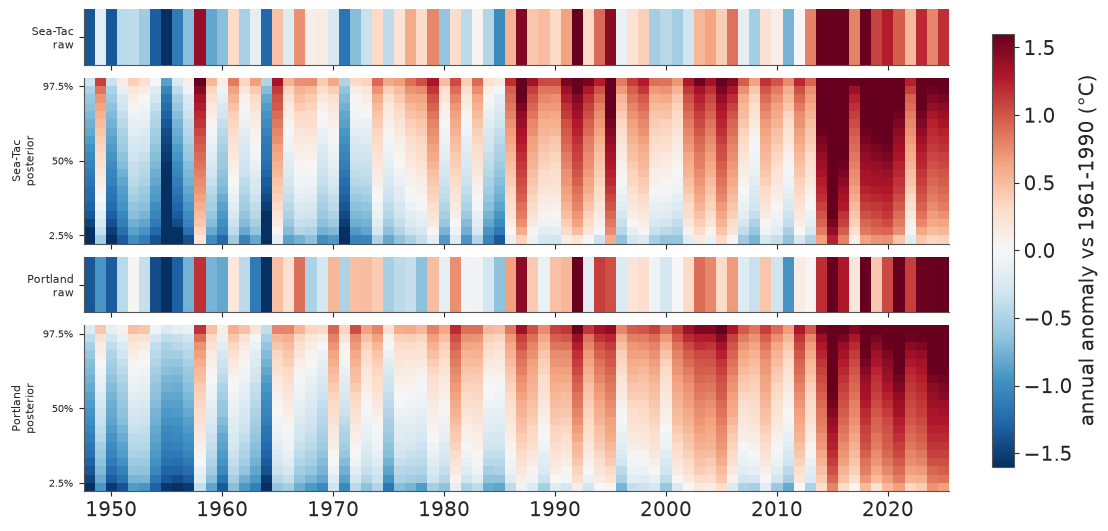

In [24]:
anomaly = level - level.sel(year=slice(1961, 1990)).mean("year")
qgrid = np.linspace(0.025, 0.975, 20)
stripes = anomaly.quantile(qgrid, dim="sample")
raw_anom = annual_obs - annual_obs.sel(year=slice(1961, 1990)).mean("year")
norm = TwoSlopeNorm(vcenter=0, vmin=-1.6, vmax=1.6)
width = stripes.sel(quantile=qgrid[-1]) - stripes.sel(quantile=qgrid[0])
print("average 95% width of a year's level (°C):",
      width.mean("year").round(2).to_series().to_dict())

fig, axes = plt.subplots(4, 1, figsize=(11, 5.2), sharex=True,
                         gridspec_kw={"height_ratios": [1, 3, 1, 3]})
for i, st in enumerate(STATIONS):
    ax_raw, ax_post = axes[2 * i], axes[2 * i + 1]
    ax_raw.imshow(raw_anom.sel(station=st).values[None, :], cmap="RdBu_r", norm=norm,
                  aspect="auto", extent=(1947.5, 2025.5, 0, 1))
    mesh = ax_post.imshow(stripes.sel(station=st).values, cmap="RdBu_r", norm=norm,
                          aspect="auto", origin="lower", extent=(1947.5, 2025.5, 0, 1))
    ax_raw.set_yticks([0.5], [f"{st}\nraw"], fontsize=8)
    ax_post.set_yticks([0.05, 0.5, 0.95], ["2.5%", "50%", "97.5%"], fontsize=7)
    ax_post.set_ylabel(f"{st}\nposterior", fontsize=8)
    for ax in (ax_raw, ax_post):
        ax.grid(False)
fig.colorbar(mesh, ax=axes, label="annual anomaly vs 1961-1990 (°C)", fraction=0.025);

Both stations show the familiar blue-to-red progression, and the posterior stripes add
two things. The colour changes within most stripes from bottom to top: the 95% interval of
one year's level is about 1.4 °C wide on average, as large as many year-to-year differences
in the middle decades - which is why the "warmest year" probabilities spread over several
years. And the levels are shrunk toward the trend line, so the posterior stripes are calmer
than the raw ones (compare Sea-Tac's 1958: deep red raw, lighter in the posterior median).

Why is a year uncertain when its annual mean is known exactly? The level is the year's
underlying warmth with day-to-day weather removed, and the model saw one day in seven -
roughly the number of effectively independent days a year contains, given the
autocorrelation of section 1.

## 7 · Anomalies, resampling and binning on the observed record

With a posterior climatology in hand, **anomalies** of every observed day are one line:
`groupby("time.dayofyear")` minus a climatology indexed by `dayofyear`. We use the
posterior-mean climatology of the 1961-1990 climate (the WMO reference period, evaluated at
its mid-point) on days 1-366, built on a dimension named `dayofyear` so that it matches the
group name.

In [25]:
all_days = xr.DataArray(np.arange(1, 367), dims="dayofyear",
                        coords={"dayofyear": np.arange(1, 367)})
base_clim = expected_tmax(post, 1975.5, all_days).mean("sample")
anom = ds.TMAX.groupby("time.dayofyear") - base_clim
print(anom.dims, "| mean anomaly 1961-1990:",
      anom.sel(time=slice("1961", "1990")).mean("time").round(2).to_series().to_dict())

('station', 'time') | mean anomaly 1961-1990: {'Sea-Tac': 0.1, 'Portland': 0.13}


The anomalies average about zero over the reference period, as they should. Now the
time machinery, all on the labelled record:

- `BinGrouper` bins years into custom, labelled periods, and passing **two groupers** to
  `groupby` gives a (period x season) table in one call. Multi-key `groupby` needs real
  coordinates: a virtual `"time.season"` works as a single key, but as a keyword key it
  raises `KeyError` - which is why `season` was attached as a coord in section 1.
- Seasons come back in alphabetical order (DJF, JJA, MAM, SON): `.sel` them into the
  calendar order.

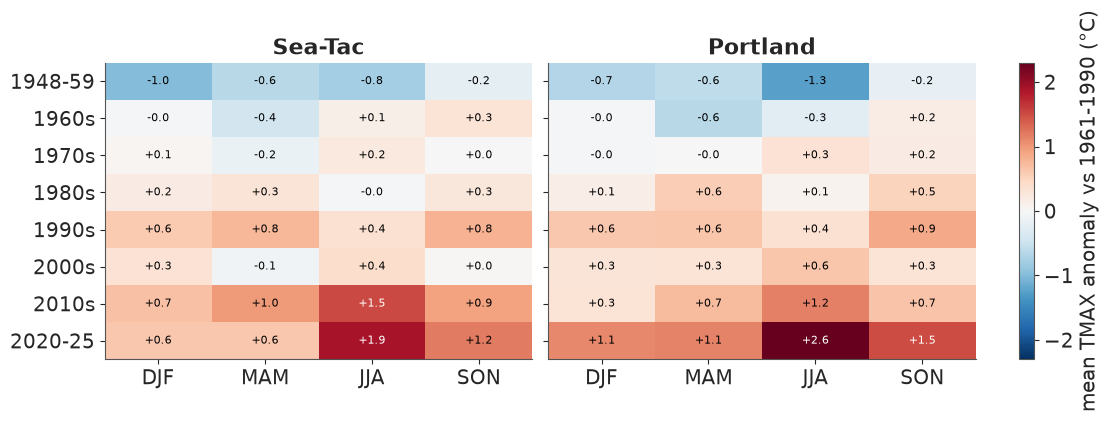

In [26]:
periods = BinGrouper(bins=[1947, 1959, 1969, 1979, 1989, 1999, 2009, 2019, 2025],
                     labels=["1948-59", "1960s", "1970s", "1980s", "1990s", "2000s", "2010s",
                             "2020-25"])
table = (anom.groupby(year=periods, season=UniqueGrouper()).mean()
         .sel(season=["DJF", "MAM", "JJA", "SON"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, st in zip(axes, STATIONS):
    t = table.sel(station=st)
    im = ax.imshow(t.transpose("year_bins", "season").values, cmap="RdBu_r",
                   norm=TwoSlopeNorm(vcenter=0, vmin=-2.3, vmax=2.3), aspect="auto")
    for (i, j), v in np.ndenumerate(t.transpose("year_bins", "season").values):
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 1.4 else "black")
    ax.set_xticks(range(4), t.season.values)
    ax.set_yticks(range(t.sizes["year_bins"]), t.year_bins.values)
    ax.set_title(st)
    ax.grid(False)
fig.colorbar(im, ax=axes, label="mean TMAX anomaly vs 1961-1990 (°C)", fraction=0.03);

The data agree with the model's seasonal warming curve and add a warning. Every season has
warmed, and the largest recent anomalies are in summer (JJA): +1.9 °C at Sea-Tac and
+2.6 °C at Portland in 2020-25, against +0.6 to +1.5 °C in the other seasons. A straight-line
trend with a gently changing seasonal cycle (our $b$ and $d$) cannot follow a jump that
size in the last few summers - the same thing the hot-day check found.

### A climate spiral

Monthly anomalies come from `.resample(time="MS").mean()`. Single months at one station are
noisy (a monthly sd of about 1.5 °C), so we average each **calendar month within each
period** - the same `BinGrouper` as above, now crossed with `month` - and draw one closed
loop per period in polar coordinates: angle = month, radius = anomaly, colour = period.
A warming climate is a set of loops that drift outward.

{'station': 2, 'year_bins': 8, 'month': 12}


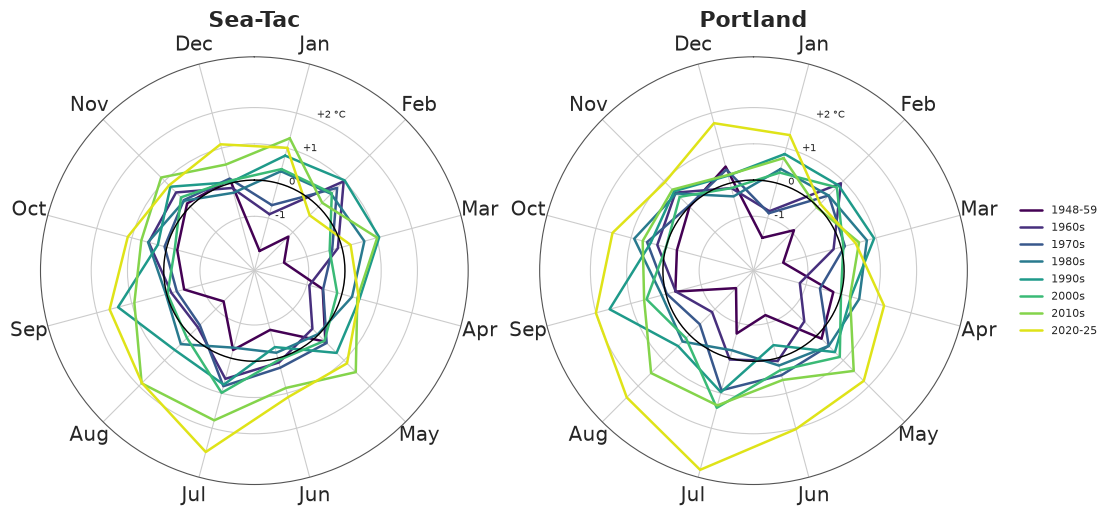

In [27]:
monthly = anom.resample(time="MS").mean()
monthly = monthly.assign_coords(year=monthly.time.dt.year, month=monthly.time.dt.month)
loops = monthly.groupby(year=periods, month=UniqueGrouper()).mean()
print(dict(loops.sizes))

OFFSET = 2.5                      # radius of the zero-anomaly ring
theta = 2 * np.pi * (loops.month.values - 0.5) / 12
colours = plt.cm.viridis(np.linspace(0, 0.95, loops.sizes["year_bins"]))
fig, axes = plt.subplots(1, 2, figsize=(11, 5.4), subplot_kw={"projection": "polar"})
for ax, st in zip(axes, STATIONS):
    for lab, col in zip(loops.year_bins.values, colours):
        r = loops.sel(station=st, year_bins=lab).values + OFFSET
        ax.plot(np.append(theta, theta[0]), np.append(r, r[0]), color=col, lw=1.8, label=lab)
    ring = np.linspace(0, 2 * np.pi, 200)
    ax.plot(ring, np.full(200, OFFSET), color="k", lw=1)
    ax.set_ylim(0, OFFSET + 3.4)
    ax.set_yticks(OFFSET + np.array([-1, 0, 1, 2]), ["-1", "0", "+1", "+2 °C"], fontsize=7)
    ax.set_xticks(theta, pd.date_range("2001-01-01", periods=12, freq="MS").strftime("%b"))
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_title(st)
axes[1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.1, 0.5));

The 1948-59 loop (darkest) runs inside or on the zero ring in almost every month; the
2020-25 loop (yellow) runs outside it in most months and bulges furthest in June-August,
2-3 °C above the 1961-1990 climate in July. The loops in between cross each other a lot:
the drift across decades is steady, but month by month it is buried in natural
variability, and this display shows both at once. The recent summer bulge is larger than
the change in any other season, as in the table above.

## 8 · Lifting a SciPy root-finder over draws with `apply_ufunc`

The **T-year return level** is the temperature $x$ that the hottest day of the year exceeds
with probability $1/T$. Under the model (independent days, year effect $u \sim N(0,\tau)$)

$$ P(\max_d \text{TMAX}_d \le x) = \mathbb{E}_u \prod_d F_d(x - u) = 1 - 1/T, $$

which has no closed form: solve it with `scipy.optimize.brentq`, integrating over $u$ with
a 7-point Gauss-Hermite rule. `brentq` takes scalars, so the solver below is written for
**one** draw, station, year and return period, with the day-of-year curves as 1-D arrays.
`xr.apply_ufunc(..., input_core_dims=[["doy"], ["doy"], ["doy"], [], []], vectorize=True)`
does the rest: `doy` is consumed, everything else (station, sample, year, period) is
broadcast and looped over, and the answer comes back labelled.

Speed matters inside a vectorised loop: with `stats.skewnorm.logcdf` in the objective this
cell took about 150 s; the same skew-normal CDF written with the ufuncs `special.ndtr` and
`special.owens_t` (checked equal) takes a few seconds.

In [28]:
gh_nodes, gh_weights = np.polynomial.hermite_e.hermegauss(7)
gh_weights = gh_weights / gh_weights.sum()


def sn_logcdf(x, alpha, xi, omega):
    z = (x - xi) / omega
    return np.log(special.ndtr(z) - 2 * special.owens_t(z, alpha))


def return_level(mean, sd, alpha, tau, period):
    """Solve P(annual max <= x) = 1 - 1/period for one draw (1-D arrays over doy)."""
    xi, omega = sn_direct(mean, sd, alpha)
    target = np.log1p(-1 / period)

    def gap(x):
        log_p = sn_logcdf(x - tau * gh_nodes[:, None], alpha, xi, omega).sum(axis=-1)
        return special.logsumexp(log_p, b=gh_weights) - target

    return optimize.brentq(gap, 15.0, 70.0, xtol=0.01)


summer = doy.sel(doy=slice(152, 273))               # June-September: where annual maxima fall
years = xr.DataArray([1967, 2006, 2025], dims="year", coords={"year": [1967, 2006, 2025]})
period = xr.DataArray([1.25, 1.5, 2, 3, 5, 10, 20, 50, 100, 200], dims="period")
period = period.assign_coords(period=period)
rl_draws = post.isel(sample=slice(0, 150))
sd, alpha = daily_spread(rl_draws, summer)
levels = xr.apply_ufunc(return_level, expected_tmax(rl_draws, years, summer), sd, alpha,
                        rl_draws["tau"], period,
                        input_core_dims=[["doy"], ["doy"], ["doy"], [], []], vectorize=True)
print(dict(levels.sizes))
levels.sel(period=[2, 10, 50, 100]).median("sample").round(1).to_dataframe(
    "median return level (°C)").unstack("period")

{'station': 2, 'sample': 150, 'year': 3, 'period': 10}


median return level (°C)                  
period                           2.0   10.0  50.0  100.0
station  year                                           
Sea-Tac  1967                     34.5  38.0  40.7  41.8
         2006                     35.6  39.1  41.9  43.0
         2025                     36.2  39.7  42.4  43.5
Portland 1967                     39.2  43.4  46.6  47.9
         2006                     40.3  44.5  47.7  48.9
         2025                     40.8  45.0  48.2  49.4

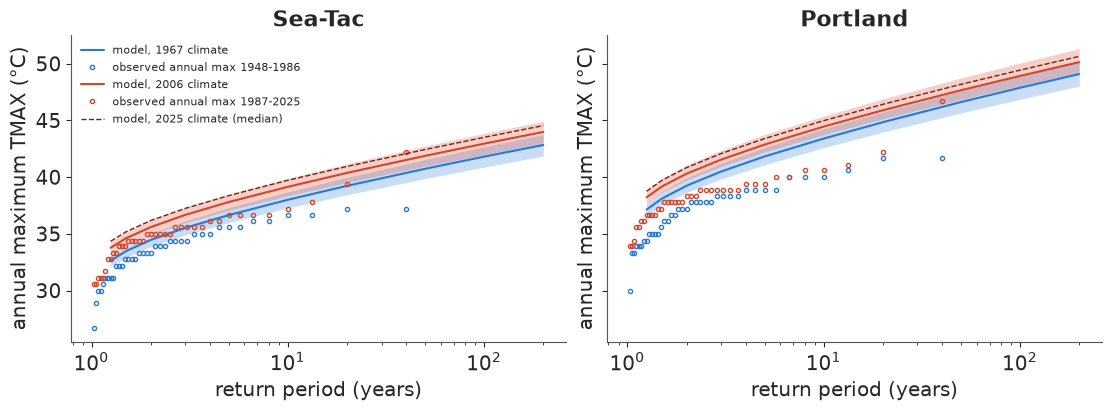

In [29]:
annual_max = ds.TMAX.groupby("year").max()
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, st in zip(axes, STATIONS):
    for yr, (lo_yr, hi_yr), col in [(1967, (1948, 1986), "#2a78d6"),
                                    (2006, (1987, 2025), "#d6452a")]:
        q = levels.sel(station=st, year=yr).quantile([0.05, 0.5, 0.95], dim="sample")
        ax.fill_between(period, q.sel(quantile=0.05), q.sel(quantile=0.95), color=col,
                        alpha=0.25, lw=0)
        ax.plot(period, q.sel(quantile=0.5), color=col, label=f"model, {yr} climate")
        # empirical: the n annual maxima of each half of the record, Weibull plotting position
        m = np.sort(annual_max.sel(station=st, year=slice(lo_yr, hi_yr)).values)
        emp_T = 1 / (1 - np.arange(1, len(m) + 1) / (len(m) + 1))
        ax.plot(emp_T, m, "o", ms=3, color=col, mfc="none",
                label=f"observed annual max {lo_yr}-{hi_yr}")
    ax.plot(period, levels.sel(station=st, year=2025).median("sample"), "--", color="#7a1f0f",
            lw=1, label="model, 2025 climate (median)")
    ax.set_xscale("log")
    ax.set(title=st, xlabel="return period (years)", ylabel="annual maximum TMAX (°C)")
axes[0].legend(fontsize=8);

The model's curves move up by about 1 °C from the 1967 to the 2006 climate (and another
0.5 °C to 2025) at every return period. But at both stations the observed annual maxima of
each half of the record (circles) lie *below* the matching model curve beyond a return
period of about two years, and further below the rarer the event: the model's hottest day
of the year is too hot. Two assumptions we made knowingly cause it - independent days
(clustered hot days give fewer independent chances, as in section 5) and a skew-normal
tail that keeps going where real summer highs level off (E37's extreme-value fits find a
finite upper limit). The consequence is worth saying plainly: taken at face value this
model calls Sea-Tac's 42.2 °C of 2021 roughly a 1-in-40-year event in the 2006 climate,
while E37, modelling annual maxima directly, finds it far outside what the earlier record
supports. A daily model is fine for the bulk and for counts; extremes need an extreme-value
model. Here the point was the mechanics: a scalar SciPy solver lifted over 2 stations x 150
draws x 3 years x 10 periods = 9,000 solves by one `apply_ufunc` call.

## 9 · Summary: the moves in this notebook

| Task | By name | Instead of |
|---|---|---|
| long table -> arrays | `set_index([...]).to_xarray().to_dataset(dim="element")` | pivots and column lists |
| stack sources | `xr.concat(objs, dim=pd.Index(labels, name="station"), join="outer")` | `np.stack` and a remembered order |
| combine two records | `xr.align(..., join="inner"/"outer"/"exact")`, chosen deliberately | the default inner join silently dropping data |
| reshape a time axis | `.set_index(time=["year", "doy"]).unstack("time")`; `.stack(obs=("station", "time"))` for model rows | `reshape(78, 365)` (wrong in leap years) |
| derived quantity on a grid | a function of labelled arrays; pass `doy`/`decade` DataArrays | loops over draws and days |
| contractions | `xr.dot(coef, basis, dim=["k", "part"])` | `einsum` strings with positional letters |
| a posterior over a date | `.idxmax("doy")`, `.interp(doy=fine)`; first True of a mask via `idxmax` | `argmax` + lookups |
| intervals / bands | `.quantile([...], dim="sample")` -> a `quantile` dim to select from | `np.percentile(..., axis=...)` |
| non-ufunc functions | `xr.apply_ufunc(f, ...)`; `input_core_dims` + `vectorize=True` for scalar solvers | `.values` and re-wrapping by hand |
| ranks inside draws | `apply_ufunc(rankdata, input_core_dims=[["year"]], output_core_dims=[["year"]])` | ranking posterior means |
| anomalies | `da.groupby("time.dayofyear") - clim` | index arithmetic on day numbers |
| periods and seasons | `groupby(year=BinGrouper(...), season=UniqueGrouper())`, `groupby_bins` | nested loops and masks |
| model comparison | `xr.concat([...], dim=pd.Index([...], name="model"))` | parallel variables `p_a`, `p_b` |

## Try it yourself

1. **Nights, not days.** Refit with `TMIN` instead of `TMAX` (one word in `rows`). Is the
   warming per decade larger at night, is the seasonal pattern of warming the same, and does
   the first frost-free date (climatological TMIN crossing 0 °C in spring, via the same
   `idxmax`-on-a-mask trick) move earlier?
2. **A better trend.** Replace $b\,t$ by a smooth curve (for example a random walk over
   5-year blocks, indexed by a `block` coord) and redo the hot-day check of section 5. Does
   the 2016-2025 excess disappear? Which of the derived quantities change?
3. **Heat-wave clustering.** Fit on every day of June-August with an AR(1) daily anomaly
   (or simulate an AR(1) with the observed lag-1 correlation of 0.67 in the predictive
   draws) and recompute the predictive hot-day counts. Does the 90% interval now cover the
   observed years?